Burn Mapping research.

In [47]:
import os

os.chdir('/home/bill/GitHub/wps-research/data/bill')

**Files**

In [48]:
from fire_mapping.raster import Raster, htrim_3d

In [93]:
for i, b in enumerate( Raster('test/1009.bin').band_info_list ):
    print(i+1, b)

1 B12_pre
2 B11_pre
3 B9_pre
4 B8_pre
5 B12_post
6 B11_post
7 B9_post
8 B8_post
9 B12_diff
10 B11_diff
11 B9_diff
12 B8_diff
13 dnbr12
14 dnbr11


In [49]:
image = Raster('test/1009.bin').read_bands(band_lst=[5,6,7,8])
map_result = Raster('test/1009.bin_classified.bin').read_bands().squeeze()

In [50]:
x_size, y_size = map_result.shape

**Visualization**

In [51]:
from fire_mapping.plot_tools import plot_multiple

In [52]:
chosen_band = [0, 1, 2]
htrim_image = htrim_3d(image[..., chosen_band])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


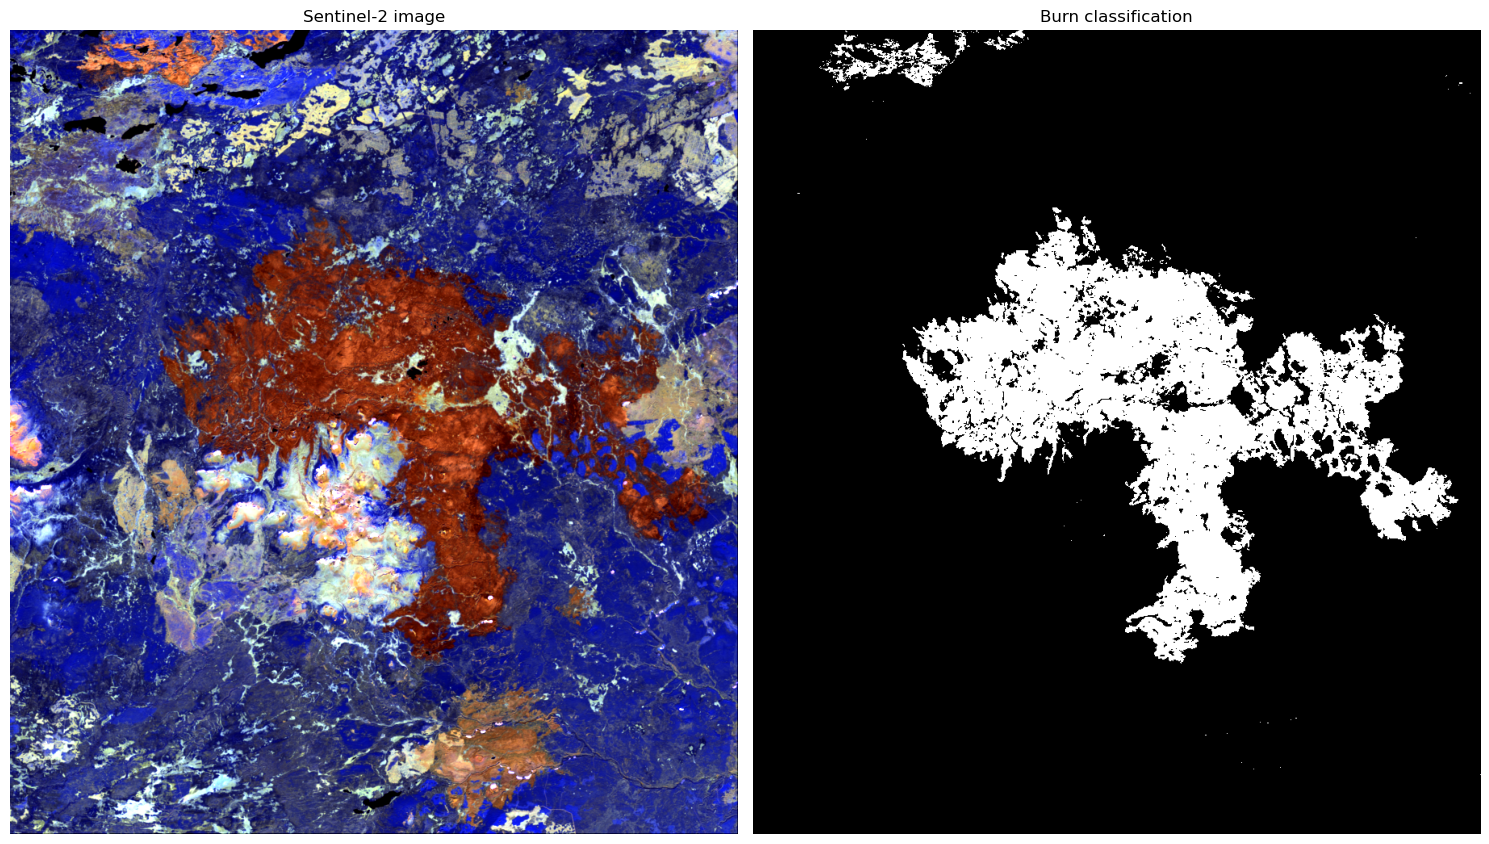

In [53]:
plot_multiple(X_list=[htrim_image, map_result], max_per_row=2, 
              title_list=[f'Sentinel-2 image', 'Burn classification'],
              figsize=(15, 9))

**Learning from Data**

Although the classification result is the product of combining this image and another one in the past, which helps extract the difference and remove 'former fire', we want to see if Using just the main raster can help us go to the exact same classification ...

... Or at least, we can learn something from it.

Machine Learning models such as 

+ Decision Trees can directly tell us about the boundary decision, which makes it a to-go choice for interpretation. 

+ Logistic Regression models Linear Relationship, which gives us the weight of each band. 

+ Random Forests can give us information about feature importance.

The next sections will walk us through some of them.

**1. Data Preparation**

In [54]:
X = image.reshape(-1, 4)
y = map_result.flatten()

In [55]:
feature_names = ['B12 SWIR', 'B11 SWIR', 'B9 Water Vapour', 'B8 NIR']

**2. Modelling**

In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [159]:
X_df = pd.DataFrame(X, columns=feature_names)

2.0.1 Correlation

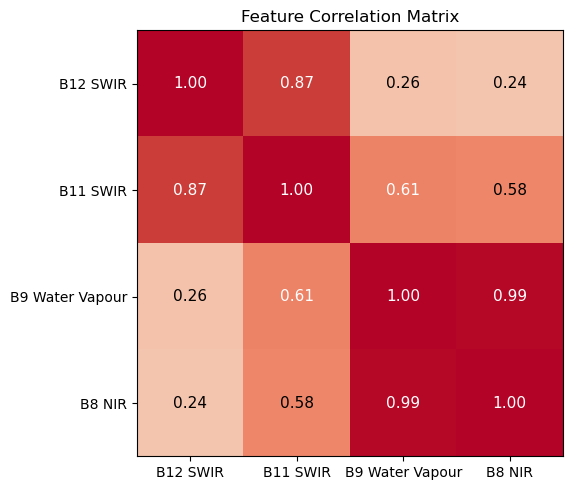

In [161]:
corr = X_df.corr().values
labels = X_df.columns

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{corr[i, j]:.2f}",
                ha="center", va="center",
                color="white" if abs(corr[i, j]) > 0.6 else "black",
                fontsize=11)

ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

2.0.2 Variance Inflation Factor

In [150]:
def compute_vif(X_df):

    X = X_df.values

    vif = []
    
    for i in range(X.shape[1]):
        y_i = X[:, i]
        X_i = np.delete(X, i, axis=1)
        # R-squared from regressing feature i on all others
        beta = np.linalg.lstsq(X_i, y_i, rcond=None)[0]
        y_hat = X_i @ beta
        ss_res = np.sum((y_i - y_hat) ** 2)
        ss_tot = np.sum((y_i - y_i.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot
        vif.append(1 / (1 - r2))
        
    return pd.DataFrame({"Feature": X_df.columns, "VIF": vif})

In [156]:
print(compute_vif(X_df))

           Feature        VIF
0         B12 SWIR   4.174468
1         B11 SWIR   7.622565
2  B9 Water Vapour  47.802830
3           B8 NIR  44.683760


In [158]:
print(compute_vif(X_df[['B12 SWIR', 'B9 Water Vapour']]))

           Feature       VIF
0         B12 SWIR  0.838287
1  B9 Water Vapour  0.529133


<u>Comments</u>: 

+ There seems to be a severe inflation (vif large) if we include features that have multicollineary (we can predict one using some others in a linear model).

+ We all know that B12 and B11 are SWIR, so they tend to vary together, same to B9 and B8. As I only keep 1 from each pair, VIR drops significantly to safe.

In [165]:
from sklearn.metrics import classification_report

2.1.1 Random Forest

In [58]:
from sklearn.ensemble import RandomForestClassifier

In [59]:
rf = RandomForestClassifier(
    n_estimators=100, 
    max_depth=3, 
    n_jobs=64
)

rf.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

2.1.2. Random Forest prediction

In [60]:
predicted_probs = rf.predict_proba(X)

predictions = (predicted_probs[:, 1] > .5).reshape(x_size, y_size)

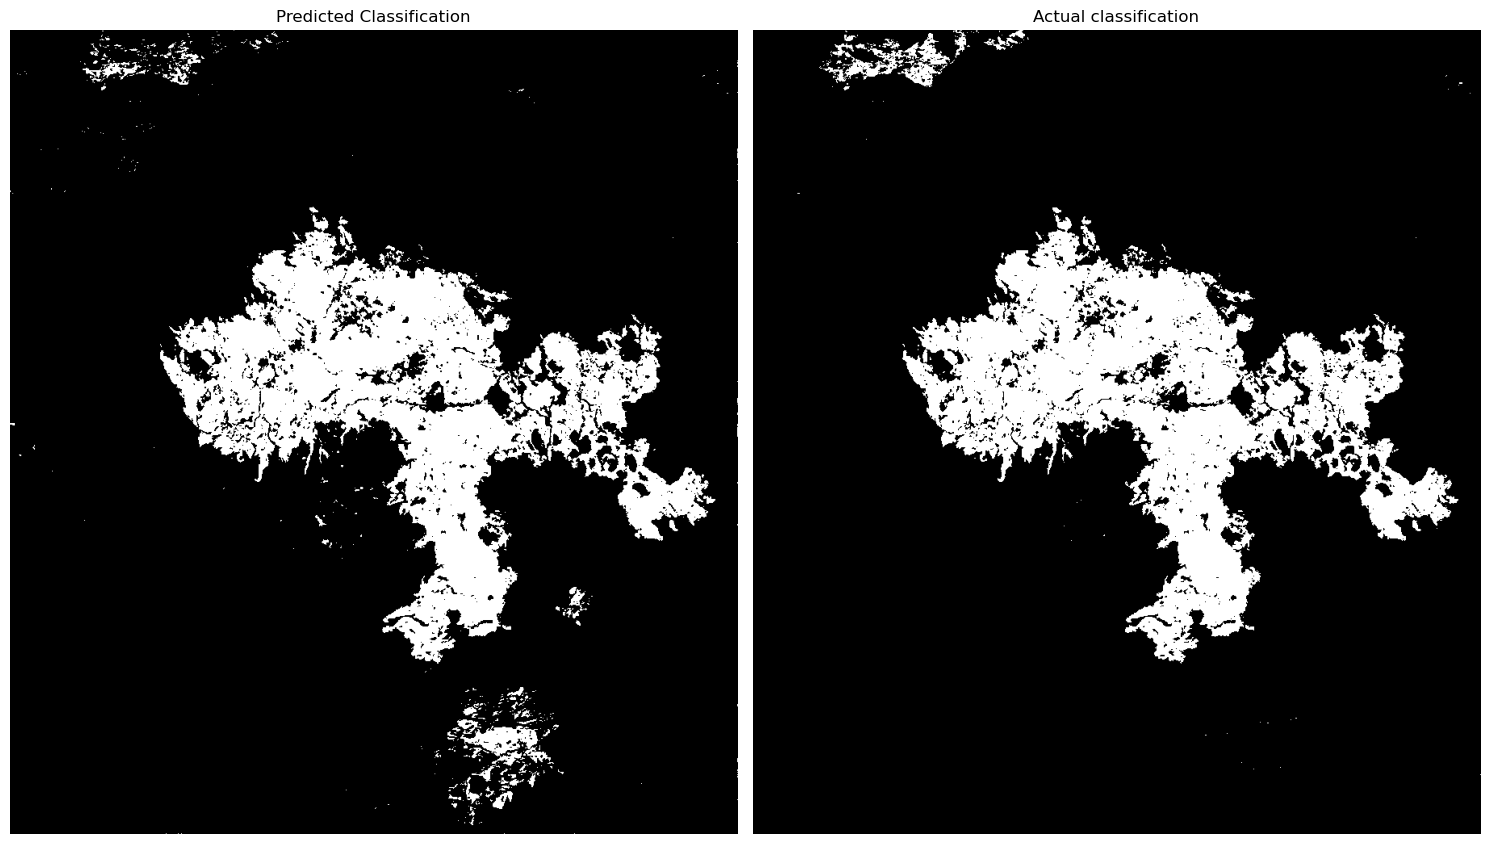

In [61]:
plot_multiple(X_list=[predictions, map_result], max_per_row=2, 
              title_list=[f'Predicted Classification', 'Actual classification'],
              figsize=(15, 9))

2.1.3 Feature Importances

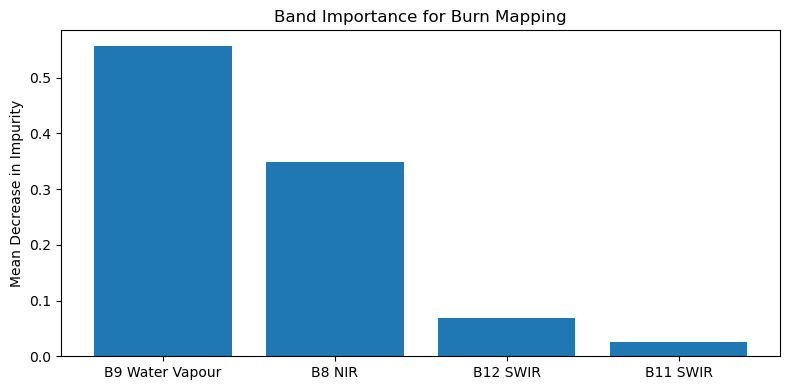

In [62]:
importances = rf.feature_importances_

# Sort by importance
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 4))
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), [feature_names[i] for i in indices])
plt.title('Band Importance for Burn Mapping')
plt.ylabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.show()

2.2.2 Decision Tree

We will be using a tree from the Random Forest to see how it splits conditions.

In [63]:
tree1 = rf.estimators_[10]

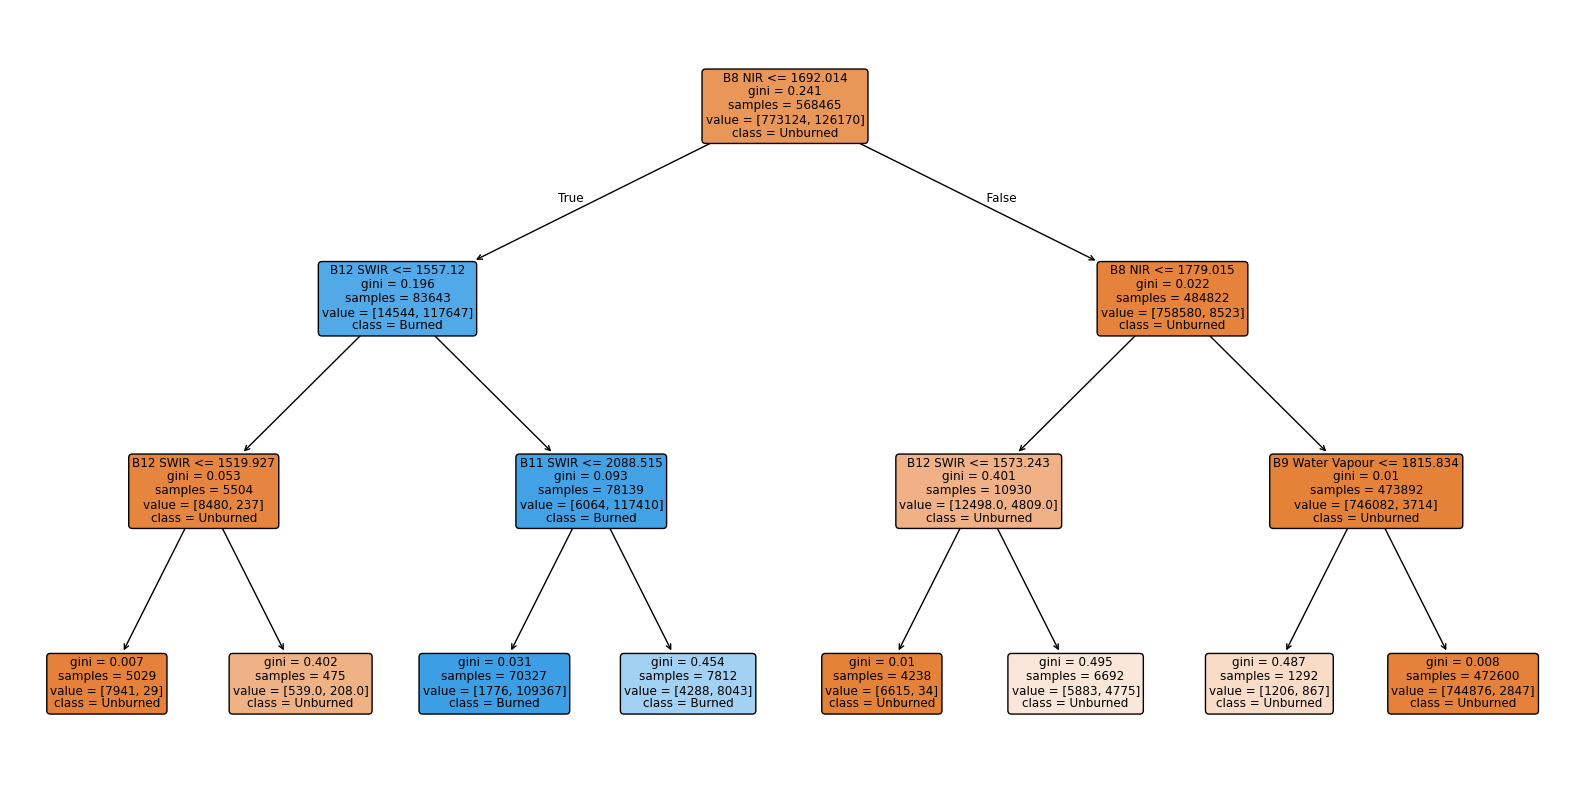

In [64]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    tree1,
    feature_names=feature_names,
    class_names=['Unburned', 'Burned'],
    filled=True,       # color nodes by majority class
    rounded=True    
)
plt.show()

2.3.1 Logistic Regression

In [72]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [166]:
scaler  = StandardScaler()
X_s = scaler.fit_transform(X[:, [0, 2]])

In [176]:
clf = LogisticRegression(
    max_iter=1000, 
    random_state=42,
    C=.1,
    penalty='l2',
    fit_intercept=True
)

clf.fit(X_s, y)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` p

In [177]:
clf.coef_

array([[ 1.43364065, -4.64717018]])

In [180]:
clf.intercept_

array([-5.57408812])

The coefficient above is for Band 12 and Band 9 (I didnt use all 4 bands because of multicollinearity). As we can see,

+ B12 drives the decision up, but B9 drives it down even faster.

-> I think real burn usually has high B12 and low B9 (or B8 because of worse vegetation). So to get a decision of Burn at threshold of 0.5, we need B12 to be much higher than B9 (using the log odd function)

$logit(z) = \frac{1}{1 + e^{-z}}$

Where $z$ = intercept + B12 * w_1 + B9 * w_2 

= -5.57 + 1.43 B12 + B9 (-4.65)

+ At $z = 0$, logit returns 0.5. So B12 needs to be high enough compared with B9 so z is at least 0.

2.3.2 Logistic Regression Prediction

In [178]:
predicted_probs = clf.predict_proba(X_s)

predictions = (predicted_probs[:, 1] > .5).reshape(x_size, y_size)

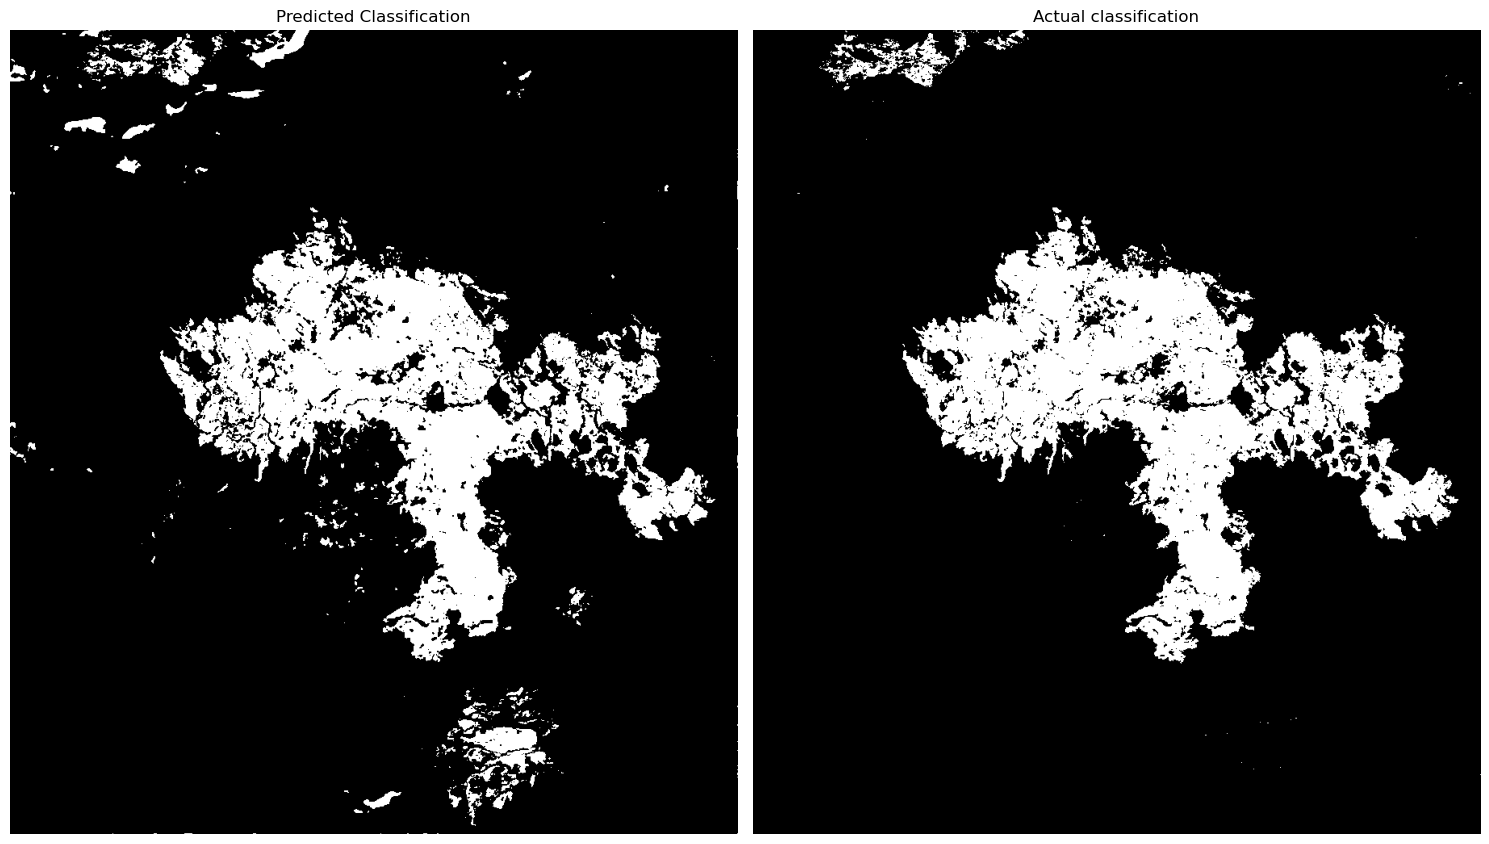

In [179]:
plot_multiple(X_list=[predictions, map_result], max_per_row=2, 
              title_list=[f'Predicted Classification', 'Actual classification'],
              figsize=(15, 9))

**Acknowledgement**

Whatever I just did might not make sense, because we still have the Ex-fire predicted as fire. 

If I can manipulate the algorithm to have them thrown away, maybe the coefficients can tell us something much different.